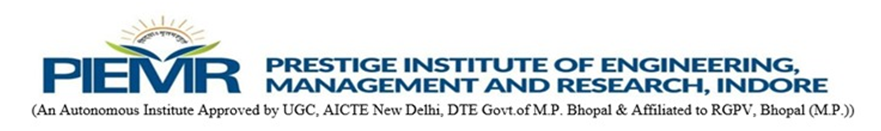

<h2 align="left">Department of Computer Science & Engineering [Internet of Things & Cybersecurity Including Blockchain Technology]</h2>

<h2 align="left">Data Analyatics in IoT & Blockchain </h2>

<h2 align="left"> Course Instructor: Dr. Rajesh Kumar</h2>

#### <h2 align="left">Experiment 6</h2>

<h2 align="left"> K-NEAREST NEIGHBOR (KNN) USING SOCIAL NETWORK ADS DATASET </h2>

<h2 align="Left">Objective</h2>

To implement the K-Nearest Neighbor (KNN) algorithm using the Social Network Ads dataset and classify whether a customer will purchase a product based on age and estimated salary



THEORY
What is K-Nearest Neighbor (KNN)?

K-Nearest Neighbor (KNN) is a supervised machine learning algorithm used for classification and regression tasks.

KNN works on the principle:

Similar data points exist close to each other.

The algorithm classifies a new data point based on the majority class of its nearest neighbors.

Python Libraries Used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)




STEP 1: Load Dataset

The Social Network Ads dataset contains:

Age
Estimated Salary
Purchased (Target Variable)

Read dataset from local system.


In [2]:
file_path = r"C:\Users\rjesh\Social_Network_Ads.csv"

df = pd.read_csv(file_path)

print(df.head())




    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


STEP 2: Explore Dataset

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDataset Information:\n")
print(df.info())




Dataset Shape: (400, 5)

Columns:

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


DATA PREPROCESSING

Machine learning models require numerical input.

Convert categorical columns into numerical format using one-hot encoding.

In [4]:
print(df.isnull().sum())




User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


FEATURE SELECTION

Select important features.

Input Features
Age
EstimatedSalary
Target Variable
Purchased

In [5]:
X = df[['Age', 'EstimatedSalary']]

y = df['Purchased']




TRAIN TEST SPLIT

Split dataset into training and testing data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)




FEATURE SCALING

KNN is distance-based.

Feature scaling is necessary because:

Salary values are much larger than Age values.
Large values dominate distance calculations.

Use StandardScaler.

In [7]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)



CREATE KNN MODEL

Create classifier using:

K=5

In [8]:
model = KNeighborsClassifier(n_neighbors=5)




TRAIN THE MODEL



In [9]:
model.fit(X_train, y_train)





,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


PREDICTIONS

Predict customer purchase behavior.

In [10]:
y_pred = model.predict(X_test)

print(y_pred)




[1 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0
 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1]


EVALUATION METRICS

Classification metrics evaluate model performance.

1. CONFUSION MATRIX
Definition

Confusion Matrix compares:

Actual values
Predicted values

|                 | Predicted Positive | Predicted Negative |
| --------------- | ------------------ | ------------------ |
| Actual Positive | TP                 | FN                 |
| Actual Negative | FP                 | TN                 |



Where:

TP = True Positive
TN = True Negative
FP = False Positive
FN = False Negative

In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)



[[59  4]
 [ 3 34]]


2. ACCURACY
Definition

Accuracy measures overall correctness.

Formula
Accuracy=
TP+TN+FP+FN/
TP+TN
	​

Interpretation
Higher accuracy indicates better performance.

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)


0.93


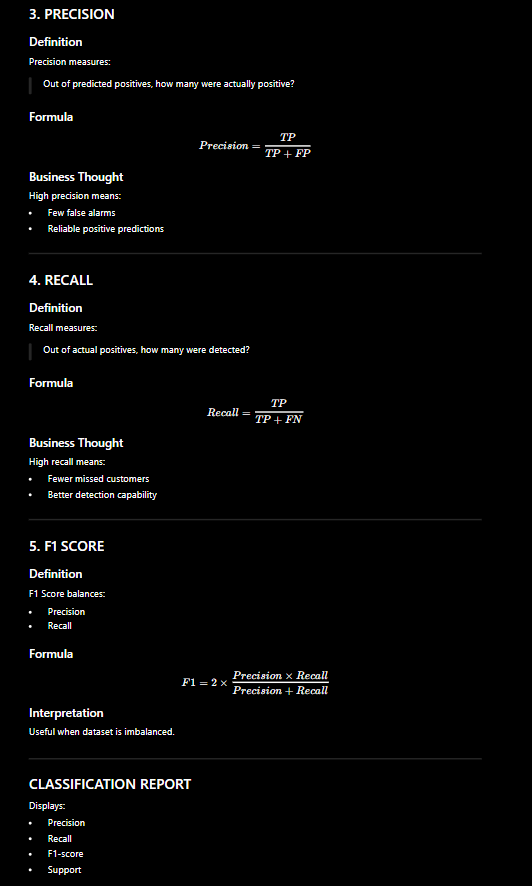


In [13]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.89      0.92      0.91        37

    accuracy                           0.93       100
   macro avg       0.92      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



COMPLETE EVALUATION CODE



In [14]:
cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy Score:")
print(accuracy)

print("Classification Report:")
print(classification_report(y_test, y_pred))




Confusion Matrix:
[[59  4]
 [ 3 34]]
Accuracy Score:
0.93
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.89      0.92      0.91        37

    accuracy                           0.93       100
   macro avg       0.92      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



ACTUAL VS PREDICTED

In [15]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(10))




     Actual  Predicted
209       0          1
280       1          1
33        0          0
210       1          1
93        0          0
84        0          0
329       1          1
94        0          0
266       0          0
126       0          0


VISUALIZATION

Visualize Age vs Estimated Salary.

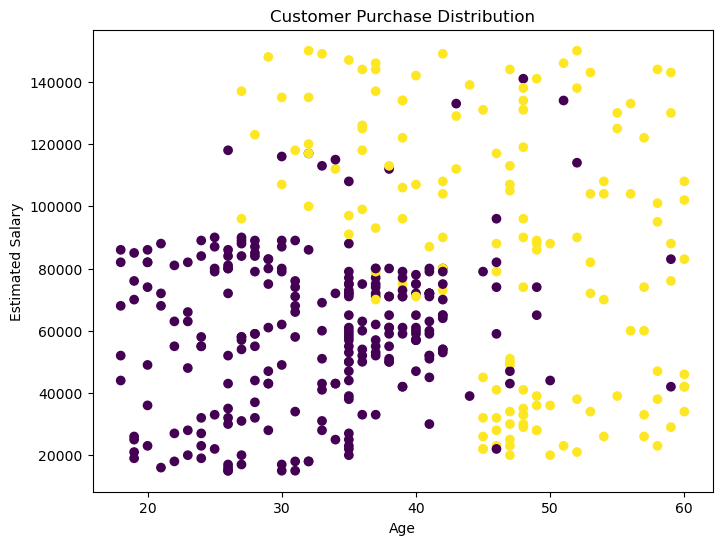

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Age'],
    df['EstimatedSalary'],
    c=df['Purchased']
)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")

plt.title("Customer Purchase Distribution")

plt.show()




SAVE OUTPUT


In [17]:
comparison.to_csv(
    r"C:\Users\rjesh\knn_output.csv",
    index=False
)

print("Output Saved Successfully")




Output Saved Successfully


VISUALIZATION

Visualize actual and predicted house Decisions.

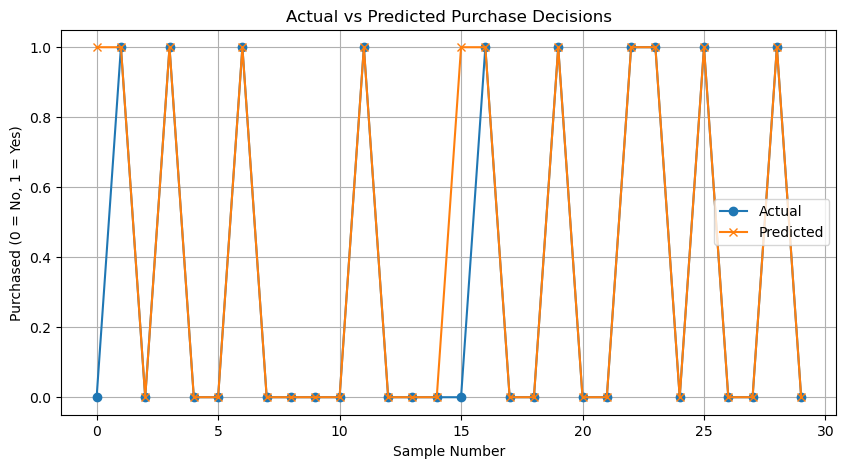

In [18]:
# Actual vs Predicted Visualization

plt.figure(figsize=(10,5))

plt.plot(
    comparison['Actual'].values[:30],
    marker='o',
    label='Actual'
)

plt.plot(
    comparison['Predicted'].values[:30],
    marker='x',
    label='Predicted'
)

plt.title("Actual vs Predicted Purchase Decisions")

plt.xlabel("Sample Number")

plt.ylabel("Purchased (0 = No, 1 = Yes)")

plt.legend()

plt.grid(True)

plt.show()

Confusion Matrix Heatmap


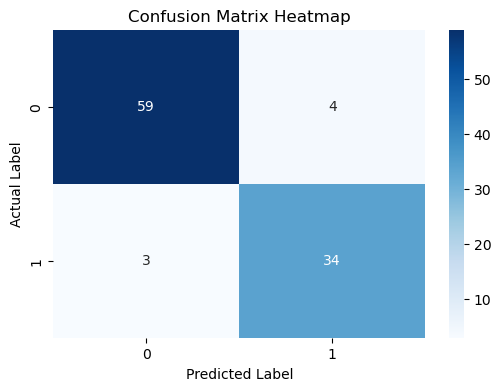

In [19]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title("Confusion Matrix Heatmap")

plt.show()

Purchase Distribution Bar Chart

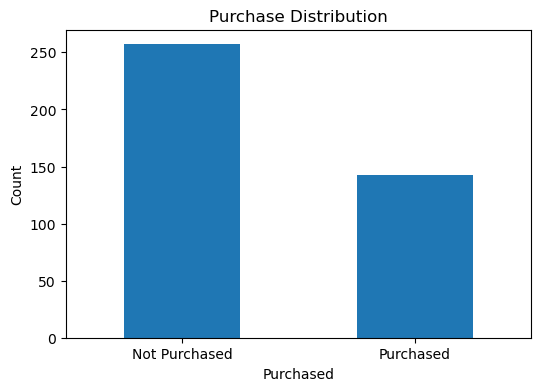

In [21]:
plt.figure(figsize=(6,4))

df['Purchased'].value_counts().plot(
    kind='bar'
)

plt.title("Purchase Distribution")

plt.xlabel("Purchased")

plt.ylabel("Count")

plt.xticks(
    [0,1],
    ['Not Purchased','Purchased'],
    rotation=0
)

plt.show()

Age vs Salary Colored by Purchase

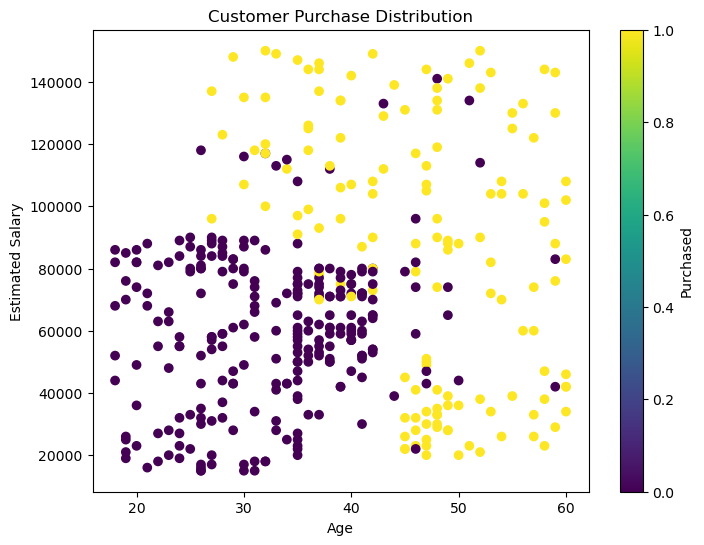

In [22]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df['Age'],
    df['EstimatedSalary'],
    c=df['Purchased']
)

plt.xlabel("Age")

plt.ylabel("Estimated Salary")

plt.title("Customer Purchase Distribution")

plt.colorbar(
    scatter,
    label="Purchased"
)

plt.show()

Decision Boundary Visualization (Training Set)

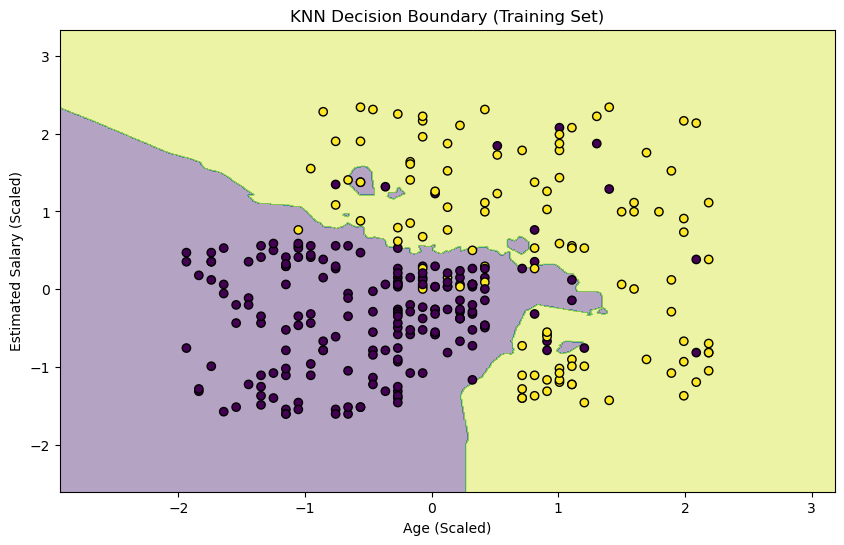

In [23]:
from matplotlib.colors import ListedColormap
import numpy as np

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(
        X_set[:,0].min()-1,
        X_set[:,0].max()+1,
        0.01
    ),
    np.arange(
        X_set[:,1].min()-1,
        X_set[:,1].max()+1,
        0.01
    )
)

plt.figure(figsize=(10,6))

plt.contourf(
    X1,
    X2,
    model.predict(
        np.array(
            [X1.ravel(), X2.ravel()]
        ).T
    ).reshape(X1.shape),
    alpha=0.4
)

plt.scatter(
    X_set[:,0],
    X_set[:,1],
    c=y_set,
    edgecolors='k'
)

plt.title("KNN Decision Boundary (Training Set)")

plt.xlabel("Age (Scaled)")

plt.ylabel("Estimated Salary (Scaled)")

plt.show()

Decision Boundary Visualization (Test Set)

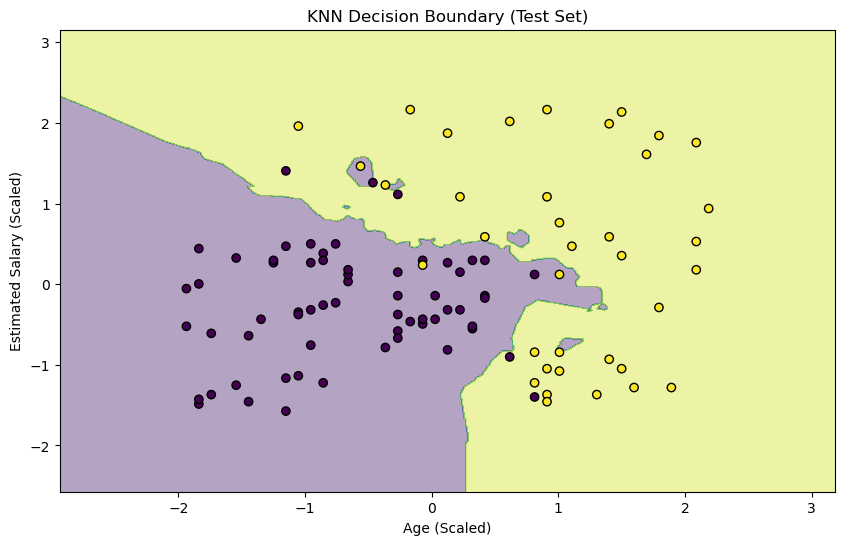

In [24]:
from matplotlib.colors import ListedColormap
import numpy as np

X_set, y_set = X_test, y_test.values

X1, X2 = np.meshgrid(
    np.arange(
        X_set[:,0].min()-1,
        X_set[:,0].max()+1,
        0.01
    ),
    np.arange(
        X_set[:,1].min()-1,
        X_set[:,1].max()+1,
        0.01
    )
)

plt.figure(figsize=(10,6))

plt.contourf(
    X1,
    X2,
    model.predict(
        np.array(
            [X1.ravel(), X2.ravel()]
        ).T
    ).reshape(X1.shape),
    alpha=0.4
)

plt.scatter(
    X_set[:,0],
    X_set[:,1],
    c=y_set,
    edgecolors='k'
)

plt.title("KNN Decision Boundary (Test Set)")

plt.xlabel("Age (Scaled)")

plt.ylabel("Estimated Salary (Scaled)")

plt.show()

In [25]:
print("="*50)
print("RESULT")
print("="*50)

print(
    f"KNN Classifier successfully trained with K = 5."
)

print(
    f"Model Accuracy = {accuracy*100:.2f}%"
)

print(
    "The classifier accurately predicts whether a customer will purchase the product based on Age and Estimated Salary."
)

RESULT
KNN Classifier successfully trained with K = 5.
Model Accuracy = 93.00%
The classifier accurately predicts whether a customer will purchase the product based on Age and Estimated Salary.


In [26]:
print("="*50)
print("CONCLUSION")
print("="*50)

print("""
The K-Nearest Neighbor (KNN) algorithm was implemented
successfully using the Social Network Ads dataset.

The model was trained using Age and Estimated Salary
features and achieved high classification accuracy.

The confusion matrix, classification report and
decision boundary plots demonstrate that KNN can
effectively classify customer purchasing behavior.

Therefore, KNN is a simple yet powerful supervised
machine learning algorithm for classification tasks.
""")

CONCLUSION

The K-Nearest Neighbor (KNN) algorithm was implemented
successfully using the Social Network Ads dataset.

The model was trained using Age and Estimated Salary
features and achieved high classification accuracy.

The confusion matrix, classification report and
decision boundary plots demonstrate that KNN can
effectively classify customer purchasing behavior.

Therefore, KNN is a simple yet powerful supervised
machine learning algorithm for classification tasks.



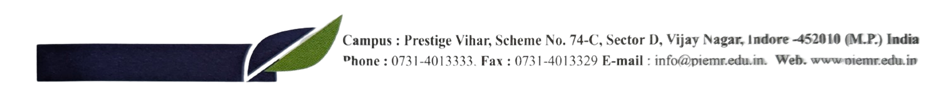